<a href="https://colab.research.google.com/github/Davi-Miguel-Rocha/Analise_Salarial_BigData/blob/main/C%C3%B3pia_de_C%C3%B3pia_de_C%C3%B3pia_de_C%C3%B3pia_de_AnaliseSalarialDataScience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Primeiras 5 linhas ---
        job_title experience_level employment_type work_models  work_year  \
0   Data Engineer        Mid-level       Full-time      Remote       2024   
1   Data Engineer        Mid-level       Full-time      Remote       2024   
2  Data Scientist     Senior-level       Full-time      Remote       2024   
3  Data Scientist     Senior-level       Full-time      Remote       2024   
4    BI Developer        Mid-level       Full-time     On-site       2024   

  employee_residence  salary salary_currency  salary_in_usd company_location  \
0      United States  148100             USD         148100    United States   
1      United States   98700             USD          98700    United States   
2      United States  140032             USD         140032    United States   
3      United States  100022             USD         100022    United States   
4      United States  120000             USD         120000    United States   

  company_size  
0       Medi

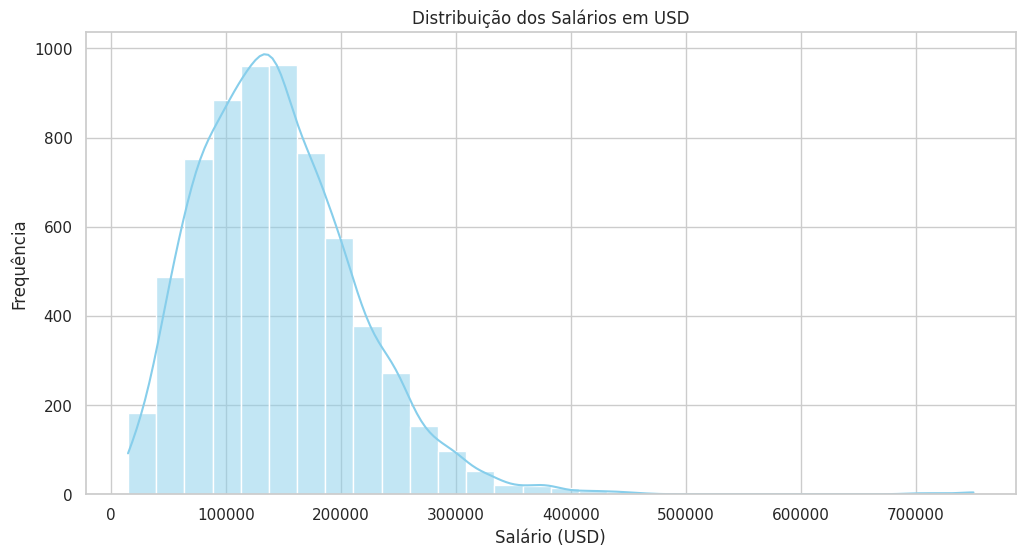

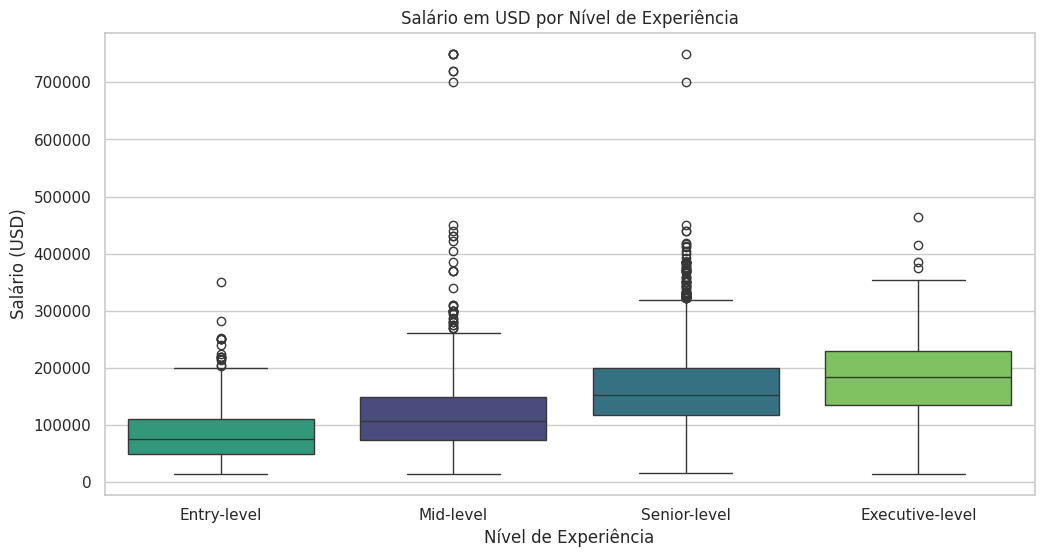

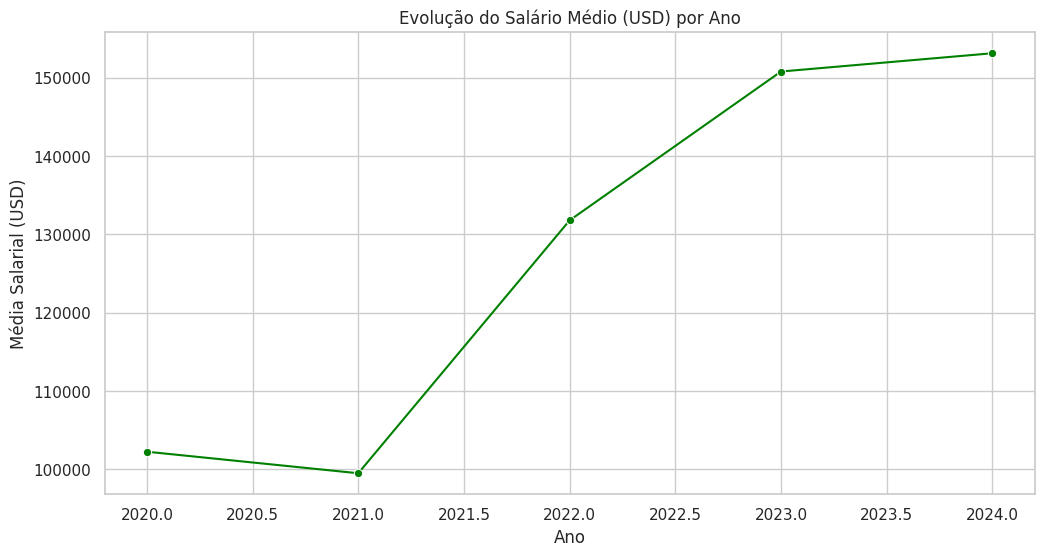

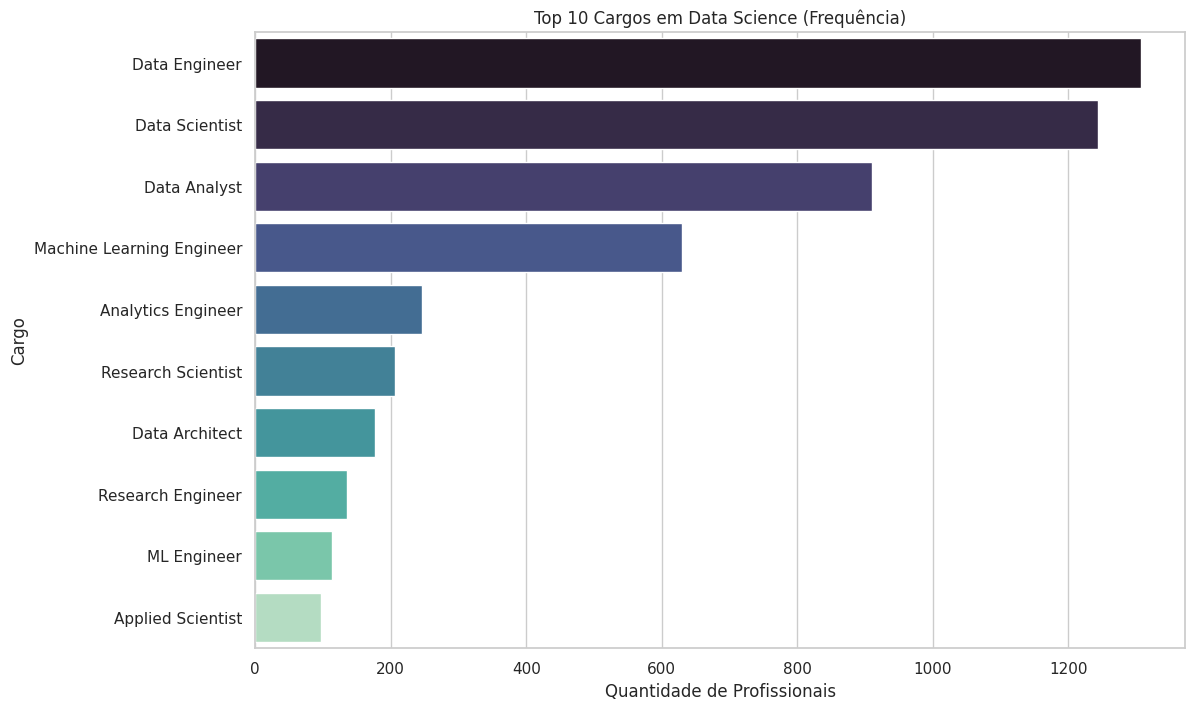

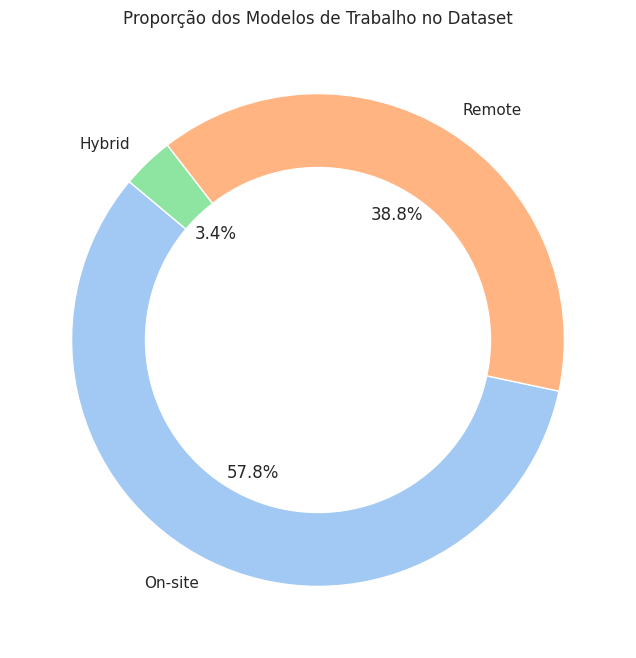

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 7.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 5.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 12.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 11.3% of the points cannot be placed;

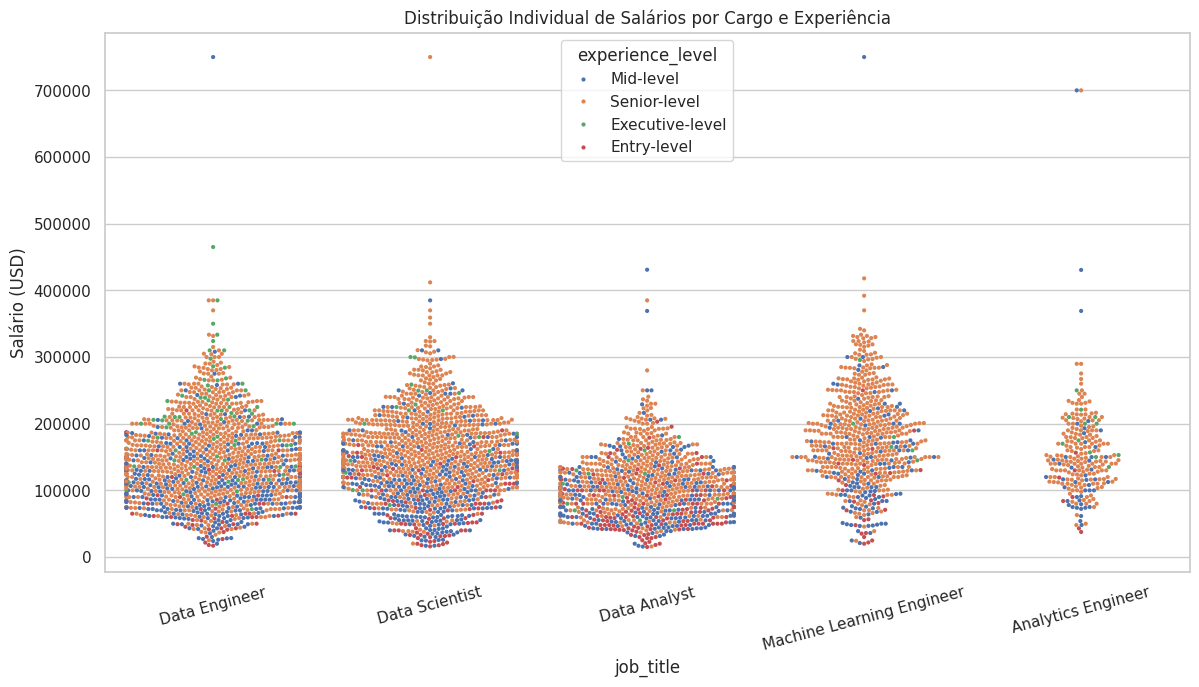

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


# Removi o index_col=0 para evitar que o job_title suma das colunas
# Corrigido o erro FileNotFoundError: Adicionando o caminho completo para o Google Drive.
df = pd.read_csv('data_science_salaries.csv')

# Visualização rápida para conferência
print("--- Primeiras 5 linhas ---")
print(df.head())
print("\n--- Informações dos Dados ---")
df.info()

# --- GRÁFICOS INICIAIS ---
print("\nGerando gráficos...")

# 1. Distribuição Salarial
plt.figure()
sns.histplot(df['salary_in_usd'], kde=True, bins=30, color='skyblue')
plt.title('Distribuição dos Salários em USD')
plt.xlabel('Salário (USD)')
plt.ylabel('Frequência')
plt.show()


exp_order = ['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level']

plt.figure()
sns.boxplot(data=df, x='experience_level', y='salary_in_usd',
            order=exp_order, hue='experience_level', palette='viridis', legend=False)
plt.title('Salário em USD por Nível de Experiência')
plt.xlabel('Nível de Experiência')
plt.ylabel('Salário (USD)')
plt.show()


plt.figure()
sns.lineplot(data=df, x='work_year', y='salary_in_usd', marker='o', color='green', errorbar=None)
plt.title('Evolução do Salário Médio (USD) por Ano')
plt.xlabel('Ano')
plt.ylabel('Média Salarial (USD)')
plt.show()

plt.figure(figsize=(12, 8))
top_jobs = df['job_title'].value_counts().nlargest(10)
# Usando hue para evitar avisos de depreciação
sns.barplot(y=top_jobs.index, x=top_jobs.values, hue=top_jobs.index, palette='mako', legend=False)
plt.title('Top 10 Cargos em Data Science (Frequência)')
plt.xlabel('Quantidade de Profissionais')
plt.ylabel('Cargo')
plt.show()


plt.figure(figsize=(8, 8))
counts = df['work_models'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
# Transforma em Donut
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporção dos Modelos de Trabalho no Dataset')
plt.show()

top_5_titles = df['job_title'].value_counts().nlargest(5).index
df_top5 = df[df['job_title'].isin(top_5_titles)]

plt.figure(figsize=(14, 7))
sns.swarmplot(data=df_top5, x='job_title', y='salary_in_usd', hue='experience_level', size=3)
plt.title('Distribuição Individual de Salários por Cargo e Experiência')
plt.xticks(rotation=15)
plt.ylabel('Salário (USD)')
plt.show()

# Modelo

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd


#puxei o csv

df = pd.read_csv('data_science_salaries.csv')


features = ['experience_level', 'employment_type', 'job_title', 'work_models',
            'employee_residence', 'company_location', 'work_year', 'company_size']

target = 'salary_in_usd'

X = df[features]
y = df[target]

# Processador para categorias e anos
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         ['experience_level', 'employment_type', 'job_title', 'work_models',
          'employee_residence', 'company_location', 'company_size']),
        ('num', StandardScaler(), ['work_year'])
    ])

X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

#construindo o modelo
modelo = tf.keras.Sequential([

    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2), # Técnica para evitar que o erro estacione

    # camadas intermediárias
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),

    # Saída única para o salário
    layers.Dense(1)
])

# Definindo o RMSprop conforme solicitado
otimizador_rmsprop = tf.keras.optimizers.RMSprop(learning_rate=0.001)

modelo.compile(
    optimizer=otimizador_rmsprop,
    loss='mae'
)

# treino do modelo que pode demorar
print("Treinando o 'Modelo' com RMSprop...")
history = modelo.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=300,
    batch_size=256,
    verbose=0
)

# os resultados eu pus num gráfico.
print("Treinamento concluído!\n")

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Erro de Treino (MAE)')
plt.plot(history.history['val_loss'], label='Erro de Validação (MAE)')
plt.title('Evolução do Aprendizado do Modelo (RMSprop)')
plt.xlabel('Épocas')
plt.ylabel('Erro em USD')
plt.legend()
plt.show()

erro_final = modelo.evaluate(X_test, y_test, verbose=0)
print(f"\nO 'Modelo' está errando, em média, ${erro_final:,.2f} por salário.")


# Fiz uma função pra predição do modelo pq se não ficaria desorganizado demeais
def prever_salario(cargo, nivel, pais, ano):
    cenario = pd.DataFrame({
        'experience_level': [nivel],
        'employment_type': ['FT'],
        'job_title': [cargo],
        'work_models': ['Remote'],
        'employee_residence': [pais],
        'company_location': [pais],
        'work_year': [ano],
        'company_size': ['M']
    })
    cenario_proc = preprocessor.transform(cenario)
    predicao = modelo.predict(cenario_proc, verbose=0)
    return predicao[0][0]

# --- 7. PROJEÇÃO SALARIAL (2024 - 2027) ---
anos_projecao = [2024, 2025, 2026, 2027]
previsoes = [prever_salario('Data Scientist', 'Senior-level', 'US', ano) for ano in anos_projecao]

plt.figure(figsize=(10, 5))
plt.plot(anos_projecao, previsoes, marker='o', color='green', linestyle='--')
plt.title('Projeção Salarial: Tendência 2024 - 2027 (Senior Data Scientist US)')
plt.xlabel('Ano')
plt.ylabel('Salário Previsto (USD)')
plt.xticks(anos_projecao)
plt.grid(True, alpha=0.3)
plt.show()

erro_final = modelo.evaluate(X_test, y_test, verbose=0)
print(f"\nErro médio do modelo: ${erro_final:,.2f}")
print(f"Estimativa para 2027: ${previsoes[-1]:,.2f}")

anos_projecao = [2024, 2025, 2026, 2027]

# Calculando projeções para os dois cargos principais
pred_scientist = [prever_salario('Data Scientist', 'Senior-level', 'US', ano) for ano in anos_projecao]
pred_engineer = [prever_salario('Data Engineer', 'Senior-level', 'US', ano) for ano in anos_projecao]

plt.figure(figsize=(12, 6))

# Linha do Data Scientist
plt.plot(anos_projecao, pred_scientist, marker='o', label='Data Scientist (Senior)',
         linewidth=3, color='#1f77b4')

# Linha do Data Engineer
plt.plot(anos_projecao, pred_engineer, marker='s', label='Data Engineer (Senior)',
         linewidth=3, linestyle='--', color='#ff7f0e')

# Estética Profissional
plt.title('Duelo de Valorização: Scientist vs Engineer (Projeção 2027)', fontsize=15)
plt.xlabel('Ano')
plt.ylabel('Salário Previsto (USD)')
plt.xticks(anos_projecao)
plt.legend()
plt.grid(True, alpha=0.2)

# Anotações dos valores finais no gráfico
plt.annotate(f'${pred_scientist[-1]:,.0f}', (2027, pred_scientist[-1]), textcoords="offset points", xytext=(0,10), ha='center')
plt.annotate(f'${pred_engineer[-1]:,.0f}', (2027, pred_engineer[-1]), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

# Resultado Final no Console
erro_final = modelo.evaluate(X_test, y_test, verbose=0)
print(f"\n--- PERFORMANCE FINAL ---")
print(f"Erro médio do modelo: ${erro_final:,.2f}")
print(f"Projeção Scientist (2027): ${pred_scientist[-1]:,.2f}")
print(f"Projeção Engineer (2027): ${pred_engineer[-1]:,.2f}")

